In [1]:
# @title Instalacja zależności (uruchom raz na początku sesji Colab)
import subprocess, sys

def apt(*pkgs):
    subprocess.run(["apt-get", "install", "-y", "-q"] + list(pkgs))

def pip(*pkgs):
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install"] + list(pkgs),
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"PIP ERROR for {pkgs}:\n{result.stderr[-2000:]}")
    else:
        print(f"OK: {pkgs}")

# Zależności systemowe potrzebne do kompilacji box2d
apt("swig", "cmake", "ffmpeg", "build-essential")

# Instalacja w kolejności: najpierw box2d-py (wymaga swig), potem reszta
pip("box2d-py")
pip("gymnasium[box2d]")
pip("stable-baselines3[extra]")
pip("moviepy")

print("\nInstalacja zakończona.")

OK: ('box2d-py',)
OK: ('gymnasium[box2d]',)
OK: ('stable-baselines3[extra]',)
OK: ('moviepy',)

Instalacja zakończona.


# Lab 5: Uczenie przez wzmacnianie w przestrzeniach ciągłych
#### Jan Jędra, Robert Jacak
**Środowisko:** CarRacing-v3 (`continuous=True`) &nbsp;|&nbsp; **Algorytm:** SAC (Soft Actor-Critic)

In [2]:
import base64
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import VecTransposeImage

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


def show_video(video_path):
    """Display MP4 inline — works in Colab and standard Jupyter."""
    b64 = base64.b64encode(open(video_path, "rb").read()).decode()
    display(HTML(
        f'<video width="640" controls autoplay loop>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        f'</video>'
    ))

Device: cuda


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# =====================================================================
# KONFIGURACJA — ustaw TEST_RUN = False dla pełnego treningu
# =====================================================================
TEST_RUN = True   # True = szybki test (~10 min), False = pełny trening (~5 godz.)

if TEST_RUN:
    N_RUNS          = 2        # docelowo 10
    TIMESTEPS       = 5_000    # docelowo 50_000  (musi być > kilka epizodów)
    N_ARCH_RUNS     = 2        # docelowo 3
    N_TIMING        = 50       # docelowo 500
    EVAL_EPISODES   = 2        # docelowo 10
    GRID_STEP       = 500      # docelowo 500
    LEARNING_STARTS = 500      # docelowo 2_000
    BUFFER_SIZE     = 20_000   # docelowo 100_000
    BATCH_SIZE      = 64       # docelowo 256
    MAX_EP_STEPS    = 300      # krótkie epizody → szybsze testy; docelowo 1000
else:
    N_RUNS          = 10
    TIMESTEPS       = 50_000
    N_ARCH_RUNS     = 3
    N_TIMING        = 500
    EVAL_EPISODES   = 10
    GRID_STEP       = 500
    LEARNING_STARTS = 2_000
    BUFFER_SIZE     = 100_000
    BATCH_SIZE      = 256
    MAX_EP_STEPS    = 1000

GRID = np.arange(0, TIMESTEPS + 1, GRID_STEP)
print(f"{'[TEST RUN]' if TEST_RUN else '[FULL RUN]'}  "
      f"N_RUNS={N_RUNS}, TIMESTEPS={TIMESTEPS:,}, MAX_EP_STEPS={MAX_EP_STEPS}, "
      f"LEARNING_STARTS={LEARNING_STARTS}, BUFFER_SIZE={BUFFER_SIZE:,}")

[TEST RUN]  N_RUNS=2, TIMESTEPS=5,000, MAX_EP_STEPS=300, LEARNING_STARTS=500, BUFFER_SIZE=20,000


## Środowisko: CarRacing-v3

CarRacing-v3 to środowisko Gymnasium symulujące jazdę samochodem po losowo generowanym torze wyścigowym. Obserwacją agenta jest obraz RGB o wymiarach 96×96×3 pikseli, gdzie dolny pasek zawiera dodatkowe wskaźniki (prędkość, żyroskop itp.). Przestrzeń akcji jest ciągła i trójwymiarowa: skręt w zakresie [-1, 1] (lewo/prawo), gaz w [0, 1] oraz hamulec w [0, 1]. Agent otrzymuje nagrodę -0.1 za każdy krok czasowy (kara za czas) oraz +1000/N za każdy nowy kafelek toru, który odwiedza (N to całkowita liczba kafelków na torze). Epizod kończy się po przejechaniu 95% okrążenia (`lap_complete_percent=0.95`), po przekroczeniu limitu 1000 kroków lub gdy samochód wyjedzie zbyt daleko poza tor. Tor jest generowany losowo przy każdym resecie środowiska, co sprawia, że uogólnienie jest wymagające.

## Algorytm: SAC (Soft Actor-Critic)

SAC (Haarnoja et al., 2018) to off-policy algorytm klasy actor-critic z maksymalizacją entropii polityki. Oprócz standardowej nagrody skumulowanej, SAC optymalizuje dodatkowy człon entropii αH(π), co zachęca agenta do eksploracji i zapobiega przedwczesnemu zbieganiu do lokalnych optimów. Parametr α (temperatura entropii) jest automatycznie dostrajany podczas treningu (`ent_coef="auto"`). SAC używa dwóch niezależnych sieci krytyka (twin Q-networks) — brana jest wartość minimalna, co redukuje przeszacowanie Q-wartości. Algorytm przechowuje przeszłe doświadczenia w buforze odpowiedzi (replay buffer) i losowo próbkuje minibatche do aktualizacji. Dzięki temu jest stabilny i efektywny próbkowo w środowiskach z ciągłą przestrzenią akcji. W implementacji SB3 używamy polityki `CnnPolicy`, która przetwarza obserwacje obrazowe przez sieć konwolucyjną NatureCNN, a następnie MLP aktora i krytyka.

---
## Sekcja A — Porównanie 3 zestawów hiperparametrów
**Zmieniany hiperparametr:** `learning_rate` ∈ {1e-4, 3e-4, 1e-3}  
Pozostałe parametry stałe: `gamma=0.99`, `buffer_size`, `batch_size`, `learning_starts`, `train_freq=1`, `gradient_steps=1`, `ent_coef="auto"`  
Protokół: **10 niezależnych uruchomień** (seed 0–9) × **50 000 kroków** każde.

In [4]:
def make_env():
    return gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=True,
        lap_complete_percent=0.95,
        domain_randomize=False,
        max_episode_steps=MAX_EP_STEPS,
    )


def make_venv(log_dir, seed):
    venv = make_vec_env(make_env, n_envs=1, monitor_dir=str(log_dir), seed=seed)
    return VecTransposeImage(venv)


def interpolate_rewards(x, y, grid):
    """Interpolate episode rewards onto a common timestep grid."""
    if len(x) < 2:
        return np.full(len(grid), np.nan)
    return np.interp(grid, x, y)

In [5]:
# Timing: czas jednego kroku środowiska
env_time = make_env()
obs, _ = env_time.reset()
t0 = time.perf_counter()
for _ in range(N_TIMING):
    action = env_time.action_space.sample()
    obs, r, term, trunc, _ = env_time.step(action)
    if term or trunc:
        obs, _ = env_time.reset()
elapsed = time.perf_counter() - t0
env_time.close()

ms_per_step = elapsed / N_TIMING * 1000
steps_per_sec = N_TIMING / elapsed
print(f"Czas kroku środowiska: {ms_per_step:.2f} ms/krok  ({steps_per_sec:.0f} kroków/s)")

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Czas kroku środowiska: 8.14 ms/krok  (123 kroków/s)


In [6]:
LRS = [1e-4, 3e-4, 1e-3]

SAC_KWARGS = dict(
    gamma=0.99,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    verbose=0,
    device=DEVICE,
)

all_rewards = {}  # lr -> np.array shape (N_RUNS, len(GRID))

for lr in LRS:
    tag = f"lr_{lr:.0e}".replace("-", "m")
    rewards_runs = []

    for seed in range(N_RUNS):
        log_dir = Path(f"./logs/sac_{tag}/run_{seed:02d}")
        log_dir.mkdir(parents=True, exist_ok=True)
        ckpt_dir = Path(f"./checkpoints/sac_{tag}/run_{seed:02d}")
        ckpt_dir.mkdir(parents=True, exist_ok=True)

        venv = make_venv(log_dir, seed=seed)
        model = SAC("CnnPolicy", venv, learning_rate=lr, seed=seed, **SAC_KWARGS)

        cb = CheckpointCallback(
            save_freq=TIMESTEPS,
            save_path=str(ckpt_dir),
            name_prefix=f"sac_{tag}_s{seed:02d}",
        )
        model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=False)
        model.save(str(ckpt_dir / "final"))
        venv.close()

        x, y = ts2xy(load_results(str(log_dir)), "timesteps")
        rewards_runs.append(interpolate_rewards(x, y, GRID))
        print(f"  lr={lr:.0e}  seed={seed:02d}  done")

    all_rewards[lr] = np.array(rewards_runs)
    print(f"[lr={lr:.0e}] finished — mean final reward: {np.nanmean(all_rewards[lr][:, -10:]):.1f}")

print("\nTraining complete.")

  lr=1e-04  seed=00  done


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  lr=1e-04  seed=01  done
[lr=1e-04] finished — mean final reward: -5.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  lr=3e-04  seed=00  done


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  lr=1e-03  seed=00  done


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  lr=1e-03  seed=01  done
[lr=1e-03] finished — mean final reward: -6.2

Training complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


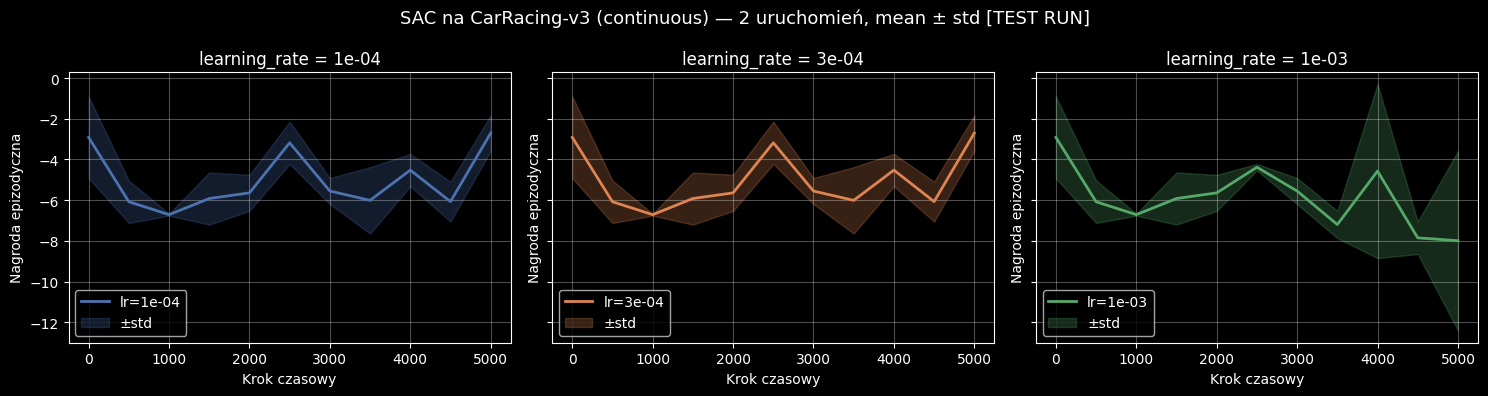


Średnia nagroda w ostatnich 10 punktach siatki:
  lr=1e-04:  mean=   -5.2  std=1.6
  lr=3e-04:  mean=   -5.2  std=1.6
  lr=1e-03:  mean=   -6.2  std=2.4


In [7]:
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, lr, color in zip(axes, LRS, colors):
    data = all_rewards[lr]
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0)
    ax.plot(GRID, mean, color=color, linewidth=2, label=f"lr={lr:.0e}")
    ax.fill_between(GRID, mean - std, mean + std, alpha=0.25, color=color, label="±std")
    ax.set_title(f"learning_rate = {lr:.0e}")
    ax.set_xlabel("Krok czasowy")
    ax.set_ylabel("Nagroda epizodyczna")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(
    f"SAC na CarRacing-v3 (continuous) — {N_RUNS} uruchomień, mean ± std"
    + (" [TEST RUN]" if TEST_RUN else ""),
    fontsize=13,
)
plt.tight_layout()
plt.savefig("learning_curves_lr.png", dpi=150)
plt.show()

print("\nŚrednia nagroda w ostatnich 10 punktach siatki:")
for lr in LRS:
    m = np.nanmean(all_rewards[lr][:, -10:])
    s = np.nanstd(all_rewards[lr][:, -10:])
    print(f"  lr={lr:.0e}:  mean={m:7.1f}  std={s:.1f}")

### Analiza zestawów hiperparametrów

*(Wypełnij po wykonaniu pełnego treningu — poniżej szablon wniosków)*

**Rozważane hiperparametry i wartości:**

| Hiperparametr | Zestaw 1 | Zestaw 2 | Zestaw 3 |
|---|---|---|---|
| `learning_rate` | 1e-4 | 3e-4 | 1e-3 |
| `gamma` | 0.99 | 0.99 | 0.99 |
| `batch_size` | 256 | 256 | 256 |
| `buffer_size` | 100 000 | 100 000 | 100 000 |
| `ent_coef` | auto | auto | auto |

**Czas jednego kroku środowiska:** *(uzupełnij z komórki timing)*

**Wnioski:** *(uzupełnij po zobaczeniu wykresów)*
- Najwyższą średnią nagrodę osiągnął zestaw z `lr=...`
- Najniższe odchylenie standardowe wykazał `lr=...`
- `lr=1e-3`: duże kroki gradientu mogą destabilizować Q-sieci SAC → większa wariancja lub gorsze wyniki
- `lr=1e-4`: uczy się wolniej, ale stabilniej — może nie zdążyć dostatecznie wzrosnąć w 50k krokach

---
## Sekcja B — Porównanie 2 architektur sieci

Obie architektury używają tego samego backbone CNN (NatureCNN z SB3), ale różnią się rozmiarem warstwy `features_dim` i głowic MLP aktora/krytyka.

**Architektura A — duża (domyślna SB3):**
- Wejście: obraz 96×96×3
- Conv2d(3→32, k=8, s=4) + ReLU → 23×23×32
- Conv2d(32→64, k=4, s=2) + ReLU → 10×10×64
- Conv2d(64→64, k=3, s=1) + ReLU → 8×8×64
- Flatten(4096) → Linear(4096→**256**) + ReLU  ← `features_dim=256`
- MLP aktora/krytyka: dwie ukryte warstwy **256** jednostek + ReLU
- Wyjście aktora: 3D ciągła akcja [skręt, gaz, hamulec]

**Architektura B — mała:**
- Ten sam backbone konwolucyjny (NatureCNN)
- Flatten(4096) → Linear(4096→**64**) + ReLU  ← `features_dim=64`
- MLP aktora/krytyka: dwie ukryte warstwy **64** jednostek + ReLU
- Wyjście aktora: 3D ciągła akcja [skręt, gaz, hamulec]

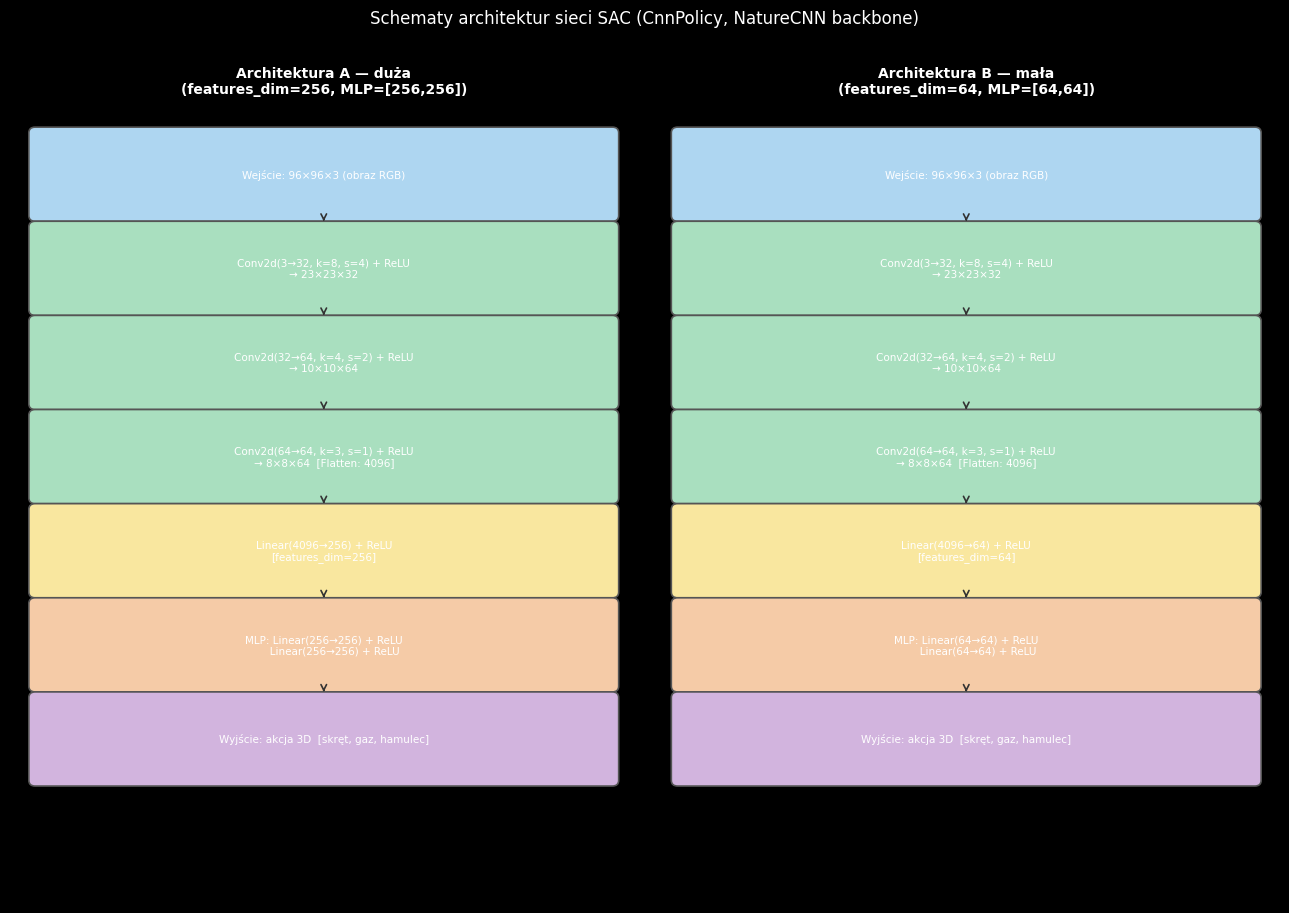

In [8]:
def draw_architecture(ax, title, features_dim, mlp_size):
    """Draw a block diagram of the SAC network architecture."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 14)
    ax.axis("off")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

    layers = [
        ("Wejście: 96×96×3 (obraz RGB)", "#AED6F1"),
        ("Conv2d(3→32, k=8, s=4) + ReLU\n→ 23×23×32", "#A9DFBF"),
        ("Conv2d(32→64, k=4, s=2) + ReLU\n→ 10×10×64", "#A9DFBF"),
        ("Conv2d(64→64, k=3, s=1) + ReLU\n→ 8×8×64  [Flatten: 4096]", "#A9DFBF"),
        (f"Linear(4096→{features_dim}) + ReLU\n[features_dim={features_dim}]", "#F9E79F"),
        (f"MLP: Linear({features_dim}→{mlp_size}) + ReLU\n       Linear({mlp_size}→{mlp_size}) + ReLU", "#F5CBA7"),
        ("Wyjście: akcja 3D  [skręt, gaz, hamulec]", "#D2B4DE"),
    ]

    box_h = 1.45
    gap = 0.2
    start_y = 13.5

    for i, (label, color) in enumerate(layers):
        y_top = start_y - i * (box_h + gap)
        rect = mpatches.FancyBboxPatch(
            (0.4, y_top - box_h), 9.2, box_h,
            boxstyle="round,pad=0.1",
            facecolor=color, edgecolor="#555", linewidth=1.2,
        )
        ax.add_patch(rect)
        ax.text(5, y_top - box_h / 2, label, ha="center", va="center", fontsize=7.5)
        if i < len(layers) - 1:
            arr_y = y_top - box_h
            ax.annotate(
                "", xy=(5, arr_y - gap + 0.05), xytext=(5, arr_y),
                arrowprops=dict(arrowstyle="->", color="#333", lw=1.2),
            )


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 9))
draw_architecture(ax1, "Architektura A — duża\n(features_dim=256, MLP=[256,256])", 256, 256)
draw_architecture(ax2, "Architektura B — mała\n(features_dim=64, MLP=[64,64])", 64, 64)
plt.suptitle("Schematy architektur sieci SAC (CnnPolicy, NatureCNN backbone)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("arch_diagrams.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
BEST_LR = max(LRS, key=lambda lr: np.nanmean(all_rewards[lr][:, -10:]))
print(f"Najlepszy LR (z Sekcji A): {BEST_LR:.0e}")

ARCH_CONFIGS = {
    "A_large_256": {
        "net_arch": [256, 256],
        "features_extractor_kwargs": {"features_dim": 256},
    },
    "B_small_64": {
        "net_arch": [64, 64],
        "features_extractor_kwargs": {"features_dim": 64},
    },
}

arch_rewards = {}

for arch_name, pkwargs in ARCH_CONFIGS.items():
    runs = []
    for seed in range(N_ARCH_RUNS):
        log_dir = Path(f"./logs/arch_{arch_name}/run_{seed:02d}")
        log_dir.mkdir(parents=True, exist_ok=True)
        ckpt_dir = Path(f"./checkpoints/arch_{arch_name}/run_{seed:02d}")
        ckpt_dir.mkdir(parents=True, exist_ok=True)

        venv = make_venv(log_dir, seed=seed)
        model = SAC(
            "CnnPolicy", venv,
            learning_rate=BEST_LR,
            policy_kwargs=pkwargs,
            seed=seed,
            **SAC_KWARGS,
        )
        model.learn(total_timesteps=TIMESTEPS, progress_bar=False)
        model.save(str(ckpt_dir / "final"))
        venv.close()

        x, y = ts2xy(load_results(str(log_dir)), "timesteps")
        runs.append(interpolate_rewards(x, y, GRID))
        print(f"  arch={arch_name}  seed={seed:02d}  done")

    arch_rewards[arch_name] = np.array(runs)
    m = np.nanmean(arch_rewards[arch_name][:, -10:])
    print(f"[{arch_name}] mean final reward: {m:.1f}")

print("\nArchitecture training complete.")

Najlepszy LR (z Sekcji A): 1e-04
  arch=A_large_256  seed=00  done


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  arch=A_large_256  seed=01  done
[A_large_256] mean final reward: -5.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  arch=B_small_64  seed=00  done


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  arch=B_small_64  seed=01  done
[B_small_64] mean final reward: -5.2

Architecture training complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


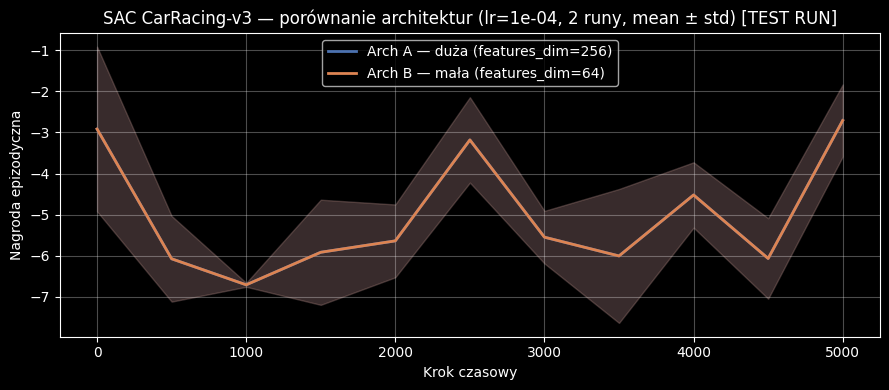


Średnia nagroda w ostatnich 10 punktach siatki:
  Arch A — duża (features_dim=256): mean=-5.2  std=1.6
  Arch B — mała (features_dim=64): mean=-5.2  std=1.6


In [10]:
arch_colors = {"A_large_256": "#4C72B0", "B_small_64": "#DD8452"}
arch_labels = {
    "A_large_256": "Arch A — duża (features_dim=256)",
    "B_small_64": "Arch B — mała (features_dim=64)",
}

plt.figure(figsize=(9, 4))
for arch_name, data in arch_rewards.items():
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0)
    c = arch_colors[arch_name]
    plt.plot(GRID, mean, color=c, linewidth=2, label=arch_labels[arch_name])
    plt.fill_between(GRID, mean - std, mean + std, alpha=0.2, color=c)

plt.xlabel("Krok czasowy")
plt.ylabel("Nagroda epizodyczna")
plt.title(
    f"SAC CarRacing-v3 — porównanie architektur (lr={BEST_LR:.0e}, {N_ARCH_RUNS} runy, mean ± std)"
    + (" [TEST RUN]" if TEST_RUN else "")
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("arch_comparison.png", dpi=150)
plt.show()

print("\nŚrednia nagroda w ostatnich 10 punktach siatki:")
for arch_name, data in arch_rewards.items():
    m = np.nanmean(data[:, -10:])
    s = np.nanstd(data[:, -10:])
    print(f"  {arch_labels[arch_name]}: mean={m:.1f}  std={s:.1f}")

---
## Sekcja C — Deterministyczny agent vs. krzywa uczenia

Wczytujemy model z najlepszym wynikiem z Sekcji A (najlepsza para `lr` + `seed`), uruchamiamy epizody z wyłączoną eksploracją (`deterministic=True`) i porównujemy wyniki z krzywą uczenia.

In [11]:
best_lr, best_seed, best_val = None, None, -np.inf
for lr in LRS:
    run_finals = np.nanmean(all_rewards[lr][:, -20:], axis=1)  # (N_RUNS,)
    # pomiń runy gdzie wszystko NaN
    valid = ~np.isnan(run_finals)
    if not valid.any():
        continue
    s = int(np.nanargmax(run_finals))
    v = run_finals[s]
    if v > best_val:
        best_val, best_lr, best_seed = v, lr, s

if best_lr is None:
    raise RuntimeError(
        "Brak kompletnych danych — żaden run nie zarejestrował zakończonych epizodów. "
        "Zwiększ TIMESTEPS lub zmniejsz MAX_EP_STEPS w komórce konfiguracyjnej."
    )

tag_best = f"lr_{best_lr:.0e}".replace("-", "m")
model_path = Path(f"./checkpoints/sac_{tag_best}/run_{best_seed:02d}/final.zip")
print(f"Najlepszy model: lr={best_lr:.0e}, seed={best_seed:02d}")
print(f"Śr. nagroda (koniec treningu): {best_val:.1f}")
print(f"Ścieżka: {model_path}")

model_eval = SAC.load(str(model_path), device=DEVICE)
print("Model wczytany.")

Najlepszy model: lr=1e-04, seed=01
Śr. nagroda (koniec treningu): -4.6
Ścieżka: checkpoints/sac_lr_1em04/run_01/final.zip
Model wczytany.


In [12]:
det_rewards = []
env_eval = make_env()

for ep in range(EVAL_EPISODES):
    obs, _ = env_eval.reset(seed=200 + ep)
    total_r = 0.0
    done = False
    while not done:
        action, _ = model_eval.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env_eval.step(action)
        total_r += r
        done = term or trunc
    det_rewards.append(total_r)
    print(f"  Epizod {ep:02d}: nagroda = {total_r:.1f}")

env_eval.close()
det_mean = np.mean(det_rewards)
det_std = np.std(det_rewards)
print(f"\nDeterministyczny agent — mean={det_mean:.1f}  std={det_std:.1f}")

  Epizod 00: nagroda = 1.5
  Epizod 01: nagroda = 7.2

Deterministyczny agent — mean=4.4  std=2.8


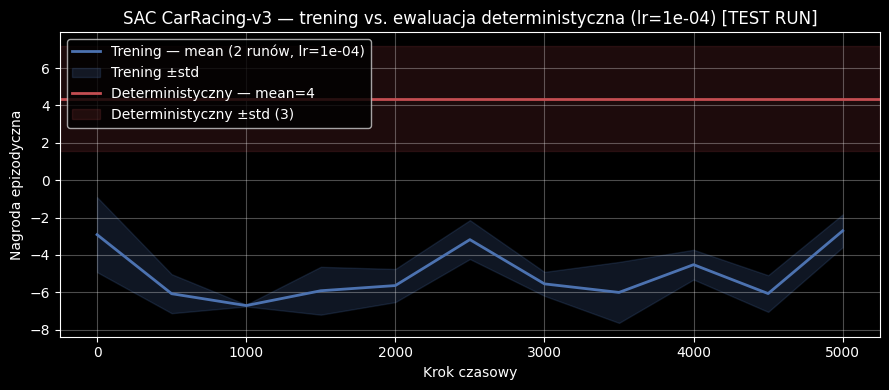

In [13]:
mean_curve = np.nanmean(all_rewards[best_lr], axis=0)
std_curve = np.nanstd(all_rewards[best_lr], axis=0)

plt.figure(figsize=(9, 4))
plt.plot(GRID, mean_curve, color="#4C72B0", linewidth=2,
         label=f"Trening — mean ({N_RUNS} runów, lr={best_lr:.0e})")
plt.fill_between(GRID, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color="#4C72B0", label="Trening ±std")
plt.axhline(det_mean, color="#C44E52", linewidth=2,
            label=f"Deterministyczny — mean={det_mean:.0f}")
plt.axhspan(det_mean - det_std, det_mean + det_std,
            alpha=0.15, color="#C44E52",
            label=f"Deterministyczny ±std ({det_std:.0f})")
plt.xlabel("Krok czasowy")
plt.ylabel("Nagroda epizodyczna")
plt.title(
    f"SAC CarRacing-v3 — trening vs. ewaluacja deterministyczna (lr={best_lr:.0e})"
    + (" [TEST RUN]" if TEST_RUN else "")
)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("det_vs_training.png", dpi=150)
plt.show()

In [14]:
# Zapis i odtworzenie wideo najlepszego agenta (deterministycznego)
video_dir = Path("./videos/best_agent")
video_dir.mkdir(parents=True, exist_ok=True)

env_vid = gym.make(
    "CarRacing-v3",
    render_mode="rgb_array",
    continuous=True,
    lap_complete_percent=0.95,
    domain_randomize=False,
)
env_vid = RecordVideo(
    env_vid,
    video_folder=str(video_dir),
    episode_trigger=lambda ep_id: True,
    disable_logger=True,
)

obs, _ = env_vid.reset(seed=42)
ep_reward = 0.0
done = False
while not done:
    action, _ = model_eval.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = env_vid.step(action)
    ep_reward += r
    done = term or trunc

env_vid.close()
latest_video = sorted(video_dir.glob("*.mp4"))[-1]
print(f"Nagroda epizodu: {ep_reward:.1f}")
print(f"Wideo zapisane: {latest_video}")
show_video(str(latest_video))

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/best_agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Nagroda epizodu: 6.0
Wideo zapisane: videos/best_agent/rl-video-episode-0.mp4
